## Custom SNN LIF neuron Python implementation for electronics engineering bachelor project

In [1]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tqdm import tqdm
import copy
import itertools

# Custom neuron implelmentation
from LIF import LIF

# Set random seed for reproducability
np.random.seed(42)

### Simulation Setup

In [2]:
pattern_box_open_right = [np.array([
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
    1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
    1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1
]), 0]

pattern_box_open_left = [np.array([
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
    0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
    0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1
]), 1]

pattern_box_open_top = [np.array([
    1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1
]), 2]

pattern_box_open_bottom = [np.array([
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
    1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1
]), 3]

# rSTDP

### Simulation setup

**Parameters for grid search**

In [35]:
# Hyperparameters
beta_range = [0.999]
threshold_range = [2.5, 3.0]                
reset_val = 0.0
learning_rate_range = [0.05]      
initial_weight_range = [0.1, 0.25, 0.5]          

# Reward parameters
dopamine_correct_range = [5.0]
dopamine_wrong_range = [-0.25]
dopamine_nofire_range = [-0.05]

# Decay parameters
global_weight_decay_range = [1.0]
threshold_decay_range = [0.002]

# Threshold parameters
threshold_increase_winner_range = [3.0]

# Pattern settings
pattern_hold_duration = 30
input_size = 15*15
output_size = 4

# Initialize history lists
mem_hist = []
thresh_hist = []
spike_hist = []
target_hist = []

# Define patterns
patterns = [
    (pattern_box_open_right[0], 0),
    (pattern_box_open_left[0], 1),
    (pattern_box_open_top[0], 2),
    (pattern_box_open_bottom[0], 3)
]

# Calculate total combinations
total_combinations = len(list(itertools.product(
    beta_range, threshold_range, learning_rate_range, initial_weight_range,
    dopamine_correct_range, dopamine_wrong_range, dopamine_nofire_range,
    global_weight_decay_range, threshold_decay_range, threshold_increase_winner_range
)))

results_snn = []
n_runs = 3
time_steps = 2500

for config in tqdm(itertools.product(
    beta_range, threshold_range, learning_rate_range, initial_weight_range,
    dopamine_correct_range, dopamine_wrong_range, dopamine_nofire_range,
    global_weight_decay_range, threshold_decay_range, threshold_increase_winner_range
), total=total_combinations):
    
    (b, thresh, lr, init_w, d_corr, d_wrng, d_nofi, w_decay, t_decay, t_inc) = config

    run_accuracies = []

    for run in range(n_runs):
        # Initialize Network
        input_to_output_synapses = np.full((input_size, output_size), init_w)
        input_neurons = [LIF(beta=b, threshold=thresh, learning_rate=lr, reset=reset_val) for _ in range(input_size)]
        output_neurons = [LIF(beta=b, threshold=thresh, learning_rate=lr, reset=reset_val) for _ in range(output_size)]
        
        correct_count = 0
        total_spike_events = 0

        # Training Loop
        for t in range(time_steps):
            pattern_idx = (t // pattern_hold_duration) % 4
            input_spikes, correct_output = patterns[pattern_idx]

            # Update input neurons
            for i in range(input_size):
                input_neurons[i].update(input_spikes[i])

            # Update output neurons
            for j in range(output_size):
                synaptic_input = np.dot(input_to_output_synapses[:, j], [n.spk for n in input_neurons])
                output_neurons[j].update(synaptic_input)

            # Winner-Take-All
            fired_indices = [j for j, n in enumerate(output_neurons) if n.spk]
            winner_idx = -1
            if len(fired_indices) > 0:
                winner_idx = np.random.choice(fired_indices)
                total_spike_events += 1
                if winner_idx == correct_output:
                    correct_count += 1
                
                for j in range(output_size):
                    if j != winner_idx:
                        output_neurons[j].spk = 0
                        output_neurons[j].mem *= 0.5
                    else:
                        output_neurons[j].threshold += t_inc

            # Reward Calculation
            if winner_idx == correct_output:
                dopamine = d_corr
            elif winner_idx == -1:
                dopamine = d_nofi
            else:
                dopamine = d_wrng

            # R-STDP & Competitive Learning
            if winner_idx != -1:
                for i in range(input_size):
                    for j in range(output_size):
                        if j == winner_idx:
                            # Winner strengthens weights based on reward
                            input_to_output_synapses[i,j] = output_neurons[j].rSTDP(
                                input_to_output_synapses[i,j], 
                                input_neurons[i].eligibility,
                                is_winner=True,
                                dopamine=dopamine
                            )
                        else:
                            # Non-winners: suppress if winner got positive reward
                            if dopamine > 0:
                                timing_factor = input_neurons[i].eligibility * input_neurons[i].eligibility
                                input_to_output_synapses[i,j] -= lr * timing_factor * dopamine * 0.3
                
                # Global weight decay
                input_to_output_synapses *= w_decay
                # Clip to prevent collapse
                input_to_output_synapses = np.clip(input_to_output_synapses, 0.1, 0.9)
                
                # Weight Normalization (Homeostasis)
                for j in range(output_size):
                    target_sum = 6
                    current_sum = np.sum(input_to_output_synapses[:, j])
                    if current_sum > 0:
                        input_to_output_synapses[:, j] *= (target_sum / current_sum)
            else:
                for n in output_neurons:
                    n.threshold = max(n.threshold - 0.05, 0.75)

            # Update thresholds based on spikes
            for j in range(output_size):
                output_neurons[j].update_threshold(threshold_decay=t_decay)

        # Calculate accuracy
        acc = correct_count / total_spike_events if total_spike_events > 0 else 0
        run_accuracies.append(acc)

    # Store Results
    results_snn.append({
        'beta': b,
        'init_threshold': thresh,
        'lr': lr,
        'init_weight': init_w,
        'd_correct': d_corr,
        'd_wrong': d_wrng,
        'd_nofire': d_nofi,
        'w_decay': w_decay,
        't_decay': t_decay,
        't_inc_winner': t_inc,
        'mean_accuracy': np.mean(run_accuracies),
        'std_accuracy': np.std(run_accuracies)
    })

# Save results
df_results = pd.DataFrame(results_snn)
df_results.to_csv("SNN_GridSearch_Results.csv", index=False)

100%|██████████| 6/6 [00:11<00:00,  1.99s/it]


In [36]:
import pandas as pd

# Load the grid search results
df = pd.read_csv("SNN_GridSearch_Results.csv")

# 1. Identify Top 10 configurations by mean accuracy
# We also want low standard deviation to ensure the result wasn't a fluke
top_10 = df.sort_values(by=['mean_accuracy', 'std_accuracy'], ascending=[False, True]).head(25)

print("=== Top 10 SNN Configurations ===")
print(top_10[['mean_accuracy', 'std_accuracy', 'beta', 'init_threshold', 'init_weight', 'd_correct', 'd_wrong', 'd_nofire', 't_inc_winner', 'w_decay', 't_decay', 'lr']])

# 2. Analyze the impact of key parameters (Averages)
print("\n=== Impact of Punishment (d_wrong) on Accuracy ===")
print(df.groupby('d_wrong')['mean_accuracy'].mean())

print("\n=== Impact of Threshold Increase on Accuracy ===")
print(df.groupby('t_inc_winner')['mean_accuracy'].mean())

# 3. Filter for 'Stable' high performers
# (Accuracy > 80% and Standard Deviation < 5%)
stable_high_performers = df[(df['mean_accuracy'] > 0.8) & (df['std_accuracy'] < 0.05)]

if not stable_high_performers.empty:
    print("\n=== Most Stable High-Performing Config ===")
    print(stable_high_performers.sort_values(by='mean_accuracy', ascending=False).iloc[0])

=== Top 10 SNN Configurations ===
   mean_accuracy  std_accuracy   beta  init_threshold  init_weight  d_correct  \
0       0.310018      0.012621  0.999             2.5         0.10        5.0   
1       0.302018      0.033183  0.999             2.5         0.25        5.0   
5       0.270693      0.022182  0.999             3.0         0.50        5.0   
2       0.269906      0.006825  0.999             2.5         0.50        5.0   
4       0.267055      0.021857  0.999             3.0         0.25        5.0   
3       0.266916      0.010376  0.999             3.0         0.10        5.0   

   d_wrong  d_nofire  t_inc_winner  w_decay  t_decay    lr  
0    -0.25     -0.05           3.0      1.0    0.002  0.05  
1    -0.25     -0.05           3.0      1.0    0.002  0.05  
5    -0.25     -0.05           3.0      1.0    0.002  0.05  
2    -0.25     -0.05           3.0      1.0    0.002  0.05  
4    -0.25     -0.05           3.0      1.0    0.002  0.05  
3    -0.25     -0.05           3

### **Best parameters**

In [70]:
# Simulation parameters
time_steps = 2000

# Architecture parameter
input_size = 15*15     # Number of input neurons
output_size = 4     # Number of output neurons

# Hyperparameters
beta = 0.999
threshold = 2.5
reset_val = 0.0
learning_rate = 0.05
initial_weight = 0.25

# Reward parameters
dopamine_correct = 5.0
dopamine_wrong = -0.25
dopamine_nofire = -0.05

# Decay parameters
global_weight_decay = 1.0
threshold_decay = 0.002

# Threshold parameters
threshold_increase_winner = 3.0

# Initialize history lists
mem_hist = []
thresh_hist = []
spike_hist = []
target_hist = []


In [71]:

# Instantiate synapses as a weight matrix, with all weights starting at
input_to_output_synapses = np.full((input_size, output_size), 0.1)
#input_to_output_synapses = np.random.rand(input_size, output_size)
print(f"Sucessfully created synapse matrix {input_to_output_synapses.shape}")

# Instantiate layers as litst of neurons
input_neurons = [LIF(beta=beta, threshold=threshold, learning_rate=learning_rate, reset=reset_val) for _ in range(input_size)]
output_neurons = [LIF(beta=beta, threshold=threshold, learning_rate=learning_rate, reset=reset_val) for _ in range(output_size)]

print(f"Sucessfully created input layer with {len(input_neurons)}")
print(f"Sucessfully created output layer with {len(output_neurons)}")


Sucessfully created synapse matrix (225, 4)
Sucessfully created input layer with 225
Sucessfully created output layer with 4


In [77]:
# Four patterns
patterns = [
    (pattern_box_open_right[0], 0),
    (pattern_box_open_left[0], 1),
    (pattern_box_open_top[0], 2),
    (pattern_box_open_bottom[0], 3)
]

pattern_hold_duration = 500

for t in range(time_steps):
    # Cycle through all 4 patterns
    pattern_idx = (t // pattern_hold_duration) % 4
    input_spikes, correct_output = patterns[pattern_idx]

    # Update input layer neurons
    for i in range(input_size):
        input_neurons[i].update(input_spikes[i])

    # Capture weights before update for diagnostics
    current_weights = input_to_output_synapses.copy()

    # Update output layer neurons
    for j in range(output_size):
        synaptic_input = sum(current_weights[i,j] * input_neurons[i].spk for i in range(input_size))
        output_neurons[j].update(synaptic_input)

    # Apply winner-take-all weight updates
    fired_indices = [j for j, n in enumerate(output_neurons) if n.spk]
    winner_idx = -1
    if len(fired_indices) > 0:
        winner_idx = np.random.choice(fired_indices)
        for j in range(output_size):
            if j != winner_idx:
                output_neurons[j].spk = 0
                output_neurons[j].mem = 0
            else:
                output_neurons[j].threshold += threshold_increase_winner

    # Calculate reward based on correct response
    if winner_idx == correct_output:
        dopamine = dopamine_correct
    elif winner_idx == -1:
        # If nothing fired lower slightly
        dopamine = dopamine_nofire
    else:
        # If wrong neuron fired, punish
        dopamine = dopamine_wrong

    # Apply R-STDP with actual reward signal
    if winner_idx != -1:
        for i in range(input_size):
            for j in range(output_size):
                input_to_output_synapses[i,j] = output_neurons[j].rSTDP(
                    input_to_output_synapses[i,j], 
                    input_neurons[i].eligibility,
                    is_winner=(j == winner_idx),
                    dopamine=dopamine
                )
        # Global weight decay
        input_to_output_synapses *= global_weight_decay
        # Clip to prevent collapse
        input_to_output_synapses = np.clip(input_to_output_synapses, 0.1, 0.9)
        # Weight Normalization (Homeostasis)
        for j in range(output_size):
            target_sum = 6
            current_sum = np.sum(input_to_output_synapses[:, j])
            if current_sum > 0:
                input_to_output_synapses[:, j] *= (target_sum / current_sum)
    else:
        for n in output_neurons:
            n.threshold -= 0.05 
            n.threshold = max(n.threshold, 0.75)

    # Update thresholds based on spikes
    for j in range(output_size):
        output_neurons[j].update_threshold(threshold_decay=threshold_decay)

    # Record the state of the output layer at the end of the timestep
    mem_hist.append([n.mem for n in output_neurons])
    thresh_hist.append([n.threshold for n in output_neurons])
    spike_hist.append([n.spk for n in output_neurons])
    target_hist.append(correct_output)

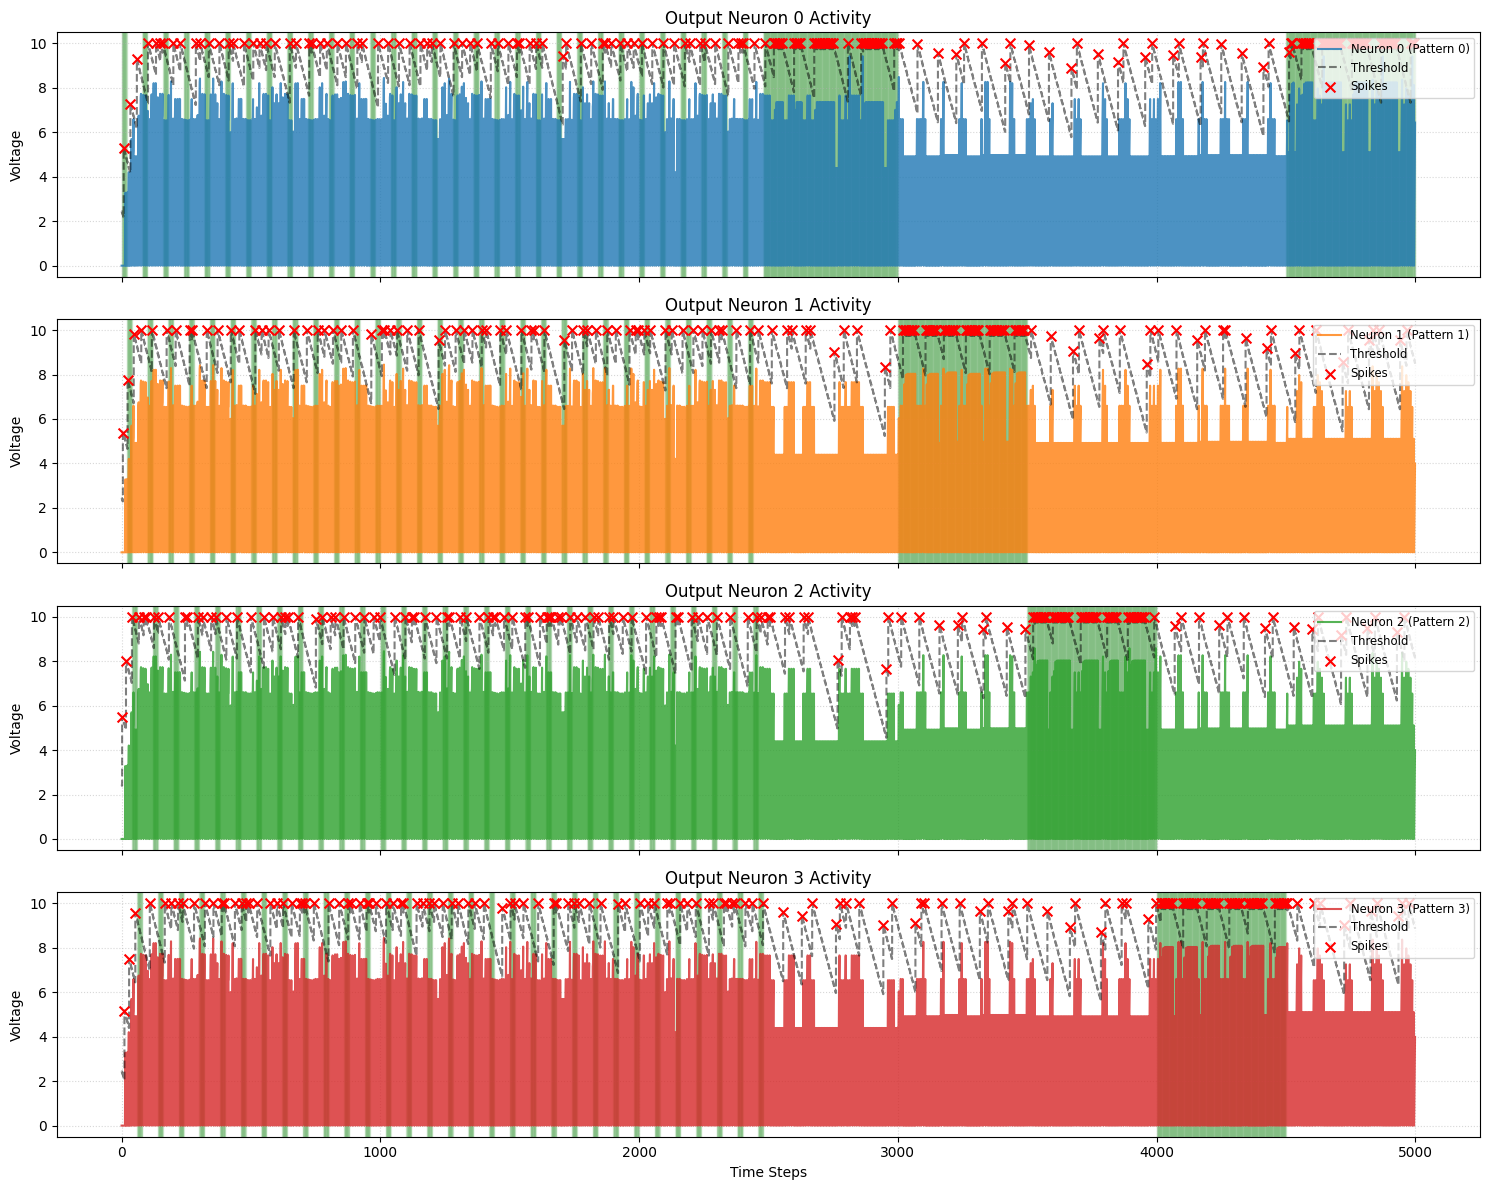


Final Accuracy: 47.8%
Correct: 325/680


In [78]:
import matplotlib.pyplot as plt
import numpy as np

def plot_neuron_dynamics(mem_history, threshold_history, spike_history, target_history):
    time_steps = len(mem_history)
    num_neurons = 4  # Specifically set for your 4-pattern simulation
    
    # Create 4 subplots (one for each neuron)
    fig, axes = plt.subplots(num_neurons, 1, figsize=(15, 12), sharex=True)
    
    # Color palette for 4 distinct neurons
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] 
    
    for i in range(num_neurons):
        # Extract individual neuron data
        mems = [m[i] for m in mem_history]
        threshs = [t[i] for t in threshold_history]
        spks = [s[i] for s in spike_history]
        
        # 1. Plot Membrane Potential
        axes[i].plot(mems, label=f'Neuron {i} (Pattern {i})', color=colors[i], alpha=0.8)
        
        # 2. Plot Dynamic Threshold
        axes[i].step(range(time_steps), threshs, label='Threshold', color='black', 
                     linestyle='--', alpha=0.5, where='post')
        
        # 3. Plot Spikes (Red 'x')
        spike_times = [t for t, s in enumerate(spks) if s > 0]
        if spike_times:
            # We plot the 'x' at the threshold level at that time
            axes[i].scatter(spike_times, [threshs[t] for t in spike_times], 
                            color='red', marker='x', s=50, label='Spikes', zorder=5)
        
        # 4. Highlight the "Target" period for this specific neuron
        # We only shade green if target_history[t] matches this neuron's index
        for t in range(time_steps):
            if target_history[t] == i:
                axes[i].axvspan(t, t+1, color='green', alpha=0.08)
        
        # Formatting
        axes[i].set_title(f"Output Neuron {i} Activity")
        axes[i].set_ylabel("Voltage")
        axes[i].legend(loc='upper right', fontsize='small')
        axes[i].grid(True, which='both', linestyle=':', alpha=0.5)

    plt.xlabel("Time Steps")
    plt.tight_layout()
    plt.show()

# Run the updated plot
plot_neuron_dynamics(mem_hist, thresh_hist, spike_hist, target_hist)


# Add after your loop
correct_count = 0
total_count = 0

for t in range(len(spike_hist)):
    if any(spike_hist[t]):  # If any neuron fired
        winner = np.argmax(spike_hist[t])
        if winner == target_hist[t]:
            correct_count += 1
        total_count += 1

accuracy = 100 * correct_count / total_count if total_count > 0 else 0
print(f"\nFinal Accuracy: {accuracy:.1f}%")
print(f"Correct: {correct_count}/{total_count}")

In [79]:
# Simulation parameters
time_steps = 2500

# Initialize history lists
mem_hist = []
thresh_hist = []
spike_hist = []
target_hist = []


In [80]:

# Instantiate synapses as a weight matrix, with all weights starting at
input_to_output_synapses = np.full((input_size, output_size), 0.1)
#input_to_output_synapses = np.random.rand(input_size, output_size)
print(f"Sucessfully created synapse matrix {input_to_output_synapses.shape}")

# Instantiate layers as litst of neurons
input_neurons = [LIF(beta=beta, threshold=threshold, learning_rate=learning_rate, reset=reset_val) for _ in range(input_size)]
output_neurons = [LIF(beta=beta, threshold=threshold, learning_rate=learning_rate, reset=reset_val) for _ in range(output_size)]

print(f"Sucessfully created input layer with {len(input_neurons)}")
print(f"Sucessfully created output layer with {len(output_neurons)}")


Sucessfully created synapse matrix (225, 4)
Sucessfully created input layer with 225
Sucessfully created output layer with 4


In [81]:
# Four patterns
patterns = [
    (pattern_box_open_right[0], 0),
    (pattern_box_open_left[0], 1),
    (pattern_box_open_top[0], 2),
    (pattern_box_open_bottom[0], 3)
]

pattern_hold_duration = 20

for t in range(time_steps):
    # Cycle through all 4 patterns
    pattern_idx = (t // pattern_hold_duration) % 4
    input_spikes, correct_output = patterns[pattern_idx]

    # Update input layer neurons
    for i in range(input_size):
        input_neurons[i].update(input_spikes[i])

    # Capture weights before update for diagnostics
    current_weights = input_to_output_synapses.copy()

    # Update output layer neurons
    for j in range(output_size):
        synaptic_input = sum(current_weights[i,j] * input_neurons[i].spk for i in range(input_size))
        output_neurons[j].update(synaptic_input)

    # Apply winner-take-all weight updates
    fired_indices = [j for j, n in enumerate(output_neurons) if n.spk]
    winner_idx = -1
    if len(fired_indices) > 0:
        winner_idx = np.random.choice(fired_indices)
        for j in range(output_size):
            if j != winner_idx:
                output_neurons[j].spk = 0
                output_neurons[j].mem = 0
            else:
                output_neurons[j].threshold += threshold_increase_winner

    # Apply R-STDP with actual reward signal
    if winner_idx != -1:
        for i in range(input_size):
            for j in range(output_size):
                input_to_output_synapses[i,j] = output_neurons[j].STDP(
                    input_to_output_synapses[i,j], 
                    input_neurons[i].eligibility,
                    is_winner=(j == winner_idx),
                )
        # Global weight decay
        input_to_output_synapses *= global_weight_decay
        # Clip to prevent collapse
        input_to_output_synapses = np.clip(input_to_output_synapses, 0.1, 0.9)
        # Weight Normalization (Homeostasis)
        for j in range(output_size):
            target_sum = 6
            current_sum = np.sum(input_to_output_synapses[:, j])
            if current_sum > 0:
                input_to_output_synapses[:, j] *= (target_sum / current_sum)
    else:
        for n in output_neurons:
            n.threshold -= 0.05 
            n.threshold = max(n.threshold, 0.75)

    # Update thresholds based on spikes
    for j in range(output_size):
        output_neurons[j].update_threshold(threshold_decay=threshold_decay)

    # Record the state of the output layer at the end of the timestep
    mem_hist.append([n.mem for n in output_neurons])
    thresh_hist.append([n.threshold for n in output_neurons])
    spike_hist.append([n.spk for n in output_neurons])
    target_hist.append(correct_output)

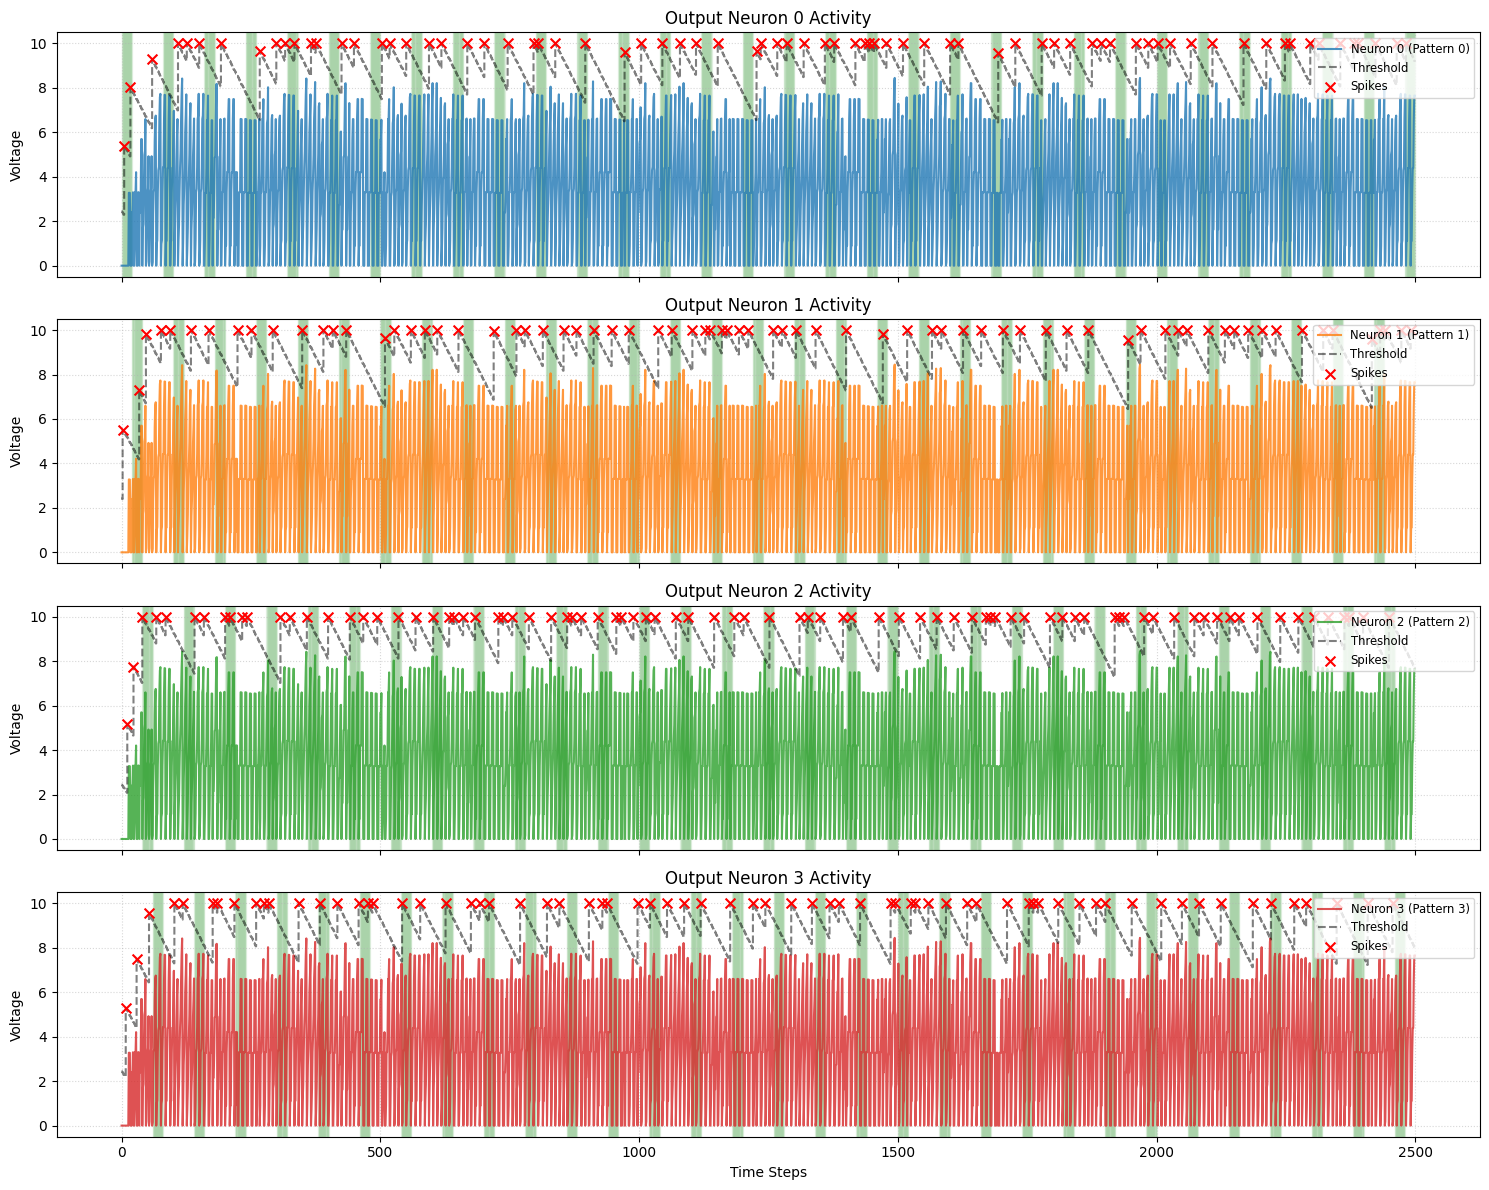


Final Accuracy: 23.1%
Correct: 70/303


In [82]:
# Run the updated plot
plot_neuron_dynamics(mem_hist, thresh_hist, spike_hist, target_hist)


# Add after your loop
correct_count = 0
total_count = 0

for t in range(len(spike_hist)):
    if any(spike_hist[t]):  # If any neuron fired
        winner = np.argmax(spike_hist[t])
        if winner == target_hist[t]:
            correct_count += 1
        total_count += 1

accuracy = 100 * correct_count / total_count if total_count > 0 else 0
print(f"\nFinal Accuracy: {accuracy:.1f}%")
print(f"Correct: {correct_count}/{total_count}")